# #3 Regression Analysis

In [1]:
# importing necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

In [2]:
# importing the data
data = pd.read_csv('cleaned_data.csv', parse_dates=['date'])

#### What will happen when we decide to go with Facebook Ad? How many facebook ad conversions are expected given a certain number of facebook ad clicks?

This is the question that will be answered using Regression Analysis.

### What is Regression?

Regression is a statistical method used to **model the relationship between variables**.

- It helps us understand how one variable affects another.
- It is commonly used for **prediction and trend analysis**.

---

### Key Concepts

- **Independent Variable (X)**: The variable used to explain or predict another variable. *(In this case: Facebook Clicks)*

- **Dependent Variable (Y)**: The variable we want to predict or understand. *(In this case: Facebook Conversions)*

---

### Model Used

We model the relationship as: $\text{Conversions} = f(\text{Clicks})$

For linear regression: $Y = \beta_0 + \beta_1 X$

Where:

- $Y$ : Dependent variable (Conversions)  
- $x$ : Independent variable (Clicks)  
- $\beta_0$ : Intercept  
- $\beta_1$ : Slope (effect of X on Y)  

---

## Why Regression is Used Here

- From the T-test, we observed that **Facebook performs better than AdWords**.
- Now, we want to understand:

  > How strongly do Facebook clicks influence conversions?

- Regression helps quantify this relationship and Predict conversions based on clicks

---

### Method: Ordinary Least Squares (OLS)

Regression finds the **best fitting line** using OLS. OLS chooses the line that minimizes the squared distance between actual values and predicted values. Those distances are called residuals.

$
\text{Residual} = \text{Actual} - \text{Predicted}
$

OLS minimizes:$\sum (\text{Residual})^2$

---

**Interpretation:**

- A **positive slope $(\beta_1)$**:
  - More clicks → More conversions  

- A **larger slope value**:
  - Stronger impact of clicks on conversions  

- A **good fit**:
  - Model predictions are close to actual values  

In [3]:
# independent variable
X = data[['facebook_ad_clicks']]

# dependent variable
Y = data[['facebook_ad_conversions']]

# initializing and fitting Linear Regression model
reg_model = LinearRegression()
reg_model.fit(X,Y)
prediction = reg_model.predict(X)

# model evaluation
r2 = r2_score(Y, prediction)*100
mse = mean_squared_error(Y, prediction)
print('Accuracy (R2 Score):',round(r2,2),'%')
print('Mean Squared Error:', round(mse,2))

Accuracy (R2 Score): 76.35 %
Mean Squared Error: 2.02


## Model Evaluation Metrics

### R² Score (Coefficient of Determination)

- The **R² score** measures how well the model explains the variability in the dependent variable.
- It ranges from **0 to 1**:
  - **1** → Perfect fit  
  - **0** → Model explains no variability  

- In this case: $R^2 = 0.7635 \ (76.35\%)$

- This means that **76.35% of the variation in Facebook conversions is explained by clicks**.

- Interpretation:
  - The model has a **good fit**
  - Clicks are a strong predictor of conversions

---

### Mean Squared Error (MSE)

- **MSE** measures the average squared difference between Actual values and predicted values.

$
MSE = \frac{1}{n} \sum (y_{\text{actual}} - y_{\text{predicted}})^2
$

- In this case: $MSE = 2.02$

- Interpretation: The prediction error is relatively **low** and on average, predictions are close to actual values.


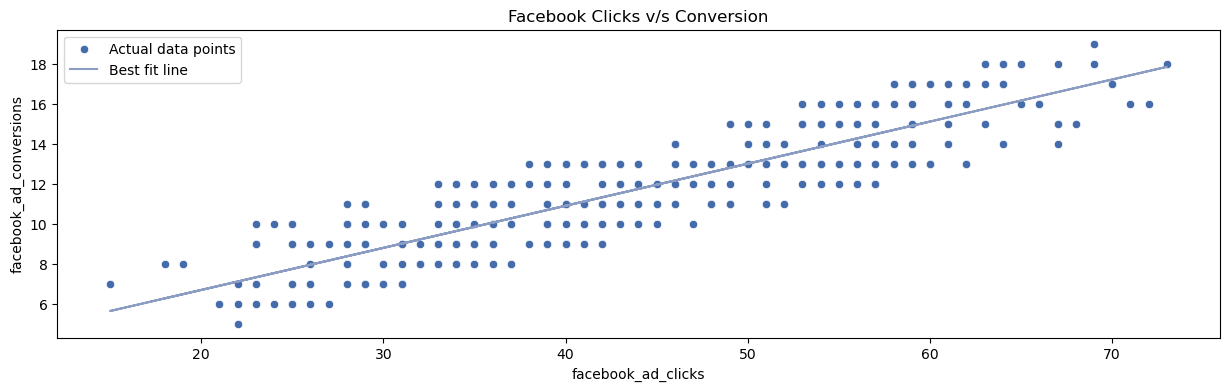

In [9]:
# plotting clicks vs conversion, along with the best fit line using the regression model

plt.figure(figsize=(15,4))
plt.title('Facebook Clicks v/s Conversion')
sns.scatterplot(x = data['facebook_ad_clicks'],y = data['facebook_ad_conversions'], color='#456caa', label = 'Actual data points')
plt.plot(data['facebook_ad_clicks'], prediction, color = '#8b9dc3', label = 'Best fit line')
plt.legend()
plt.show()

In [10]:
# predicting number of conversions based on the number of clicks using the regression model

print(f'For {50} Clicks, Expected Conversion : {round(reg_model.predict([[50]])[0][0],2)}')
print(f'For {100} Clicks, Expected Conversion : {round(reg_model.predict([[80]])[0][0],2)}')

For 50 Clicks, Expected Conversion : 13.0
For 100 Clicks, Expected Conversion : 19.31



### Predictions

- For **50 clicks** → Expected conversions ≈ **13.0**  
- For **100 clicks** → Expected conversions ≈ **19.31**
- This shows a **positive relationship** between clicks and conversions.

---

### Observations

- There is a **strong positive relationship** between Facebook clicks and conversions.
- The model explains a significant portion (**~76%**) of the variation.
- Prediction error is low, indicating **reasonable accuracy**.
- As clicks increase, conversions also increase in a **predictable manner**.

---

### Conclusion

- Facebook conversions are **strongly influenced by the number of clicks**.
- The regression model is **reliable for prediction**, though not perfect.
- Increasing clicks is likely to **increase conversions**, making it a key performance driver.
- This insight can help in Budget allocation, Campaign optimization and Performance forecasting.